In [3]:
import requests
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from networkx.algorithms.community import greedy_modularity_communities
import networkx as nx

# Project 1: Nike

On Facebook, business pages can "like" other pages, and a directed network could be derived from this liking relationship. Jane collected all the pages liked by Nike and the linking relationships among these pages. This results in two datesets:
- facebook_node_attributes.csv
- facebook_data.csv

The first dataset includes page attributes and the second data contains the edgelist information. We will visualize and explore how centrality attributes, together with other node-level attributes, could be used for spokeperson selection.




## Problem 1.1
Generate a subgraph with nodes that have more than 80,000,000 fan count. Visualize this network with node labels and upload the network graph. Make sure to use kamada_kawai_layout as the layout algorithm.

Tips: You can visualize the whole network first and then generate the subgragh.

Expected output:
- code
- gragh

> 💡 **Hint:** See class notebook **Section 1.3** for building a graph from an edgelist, **Section 1.4** for visualization parameters (including layout algorithms), and **Section 1.6** for filtering nodes by attribute and creating a subgraph.

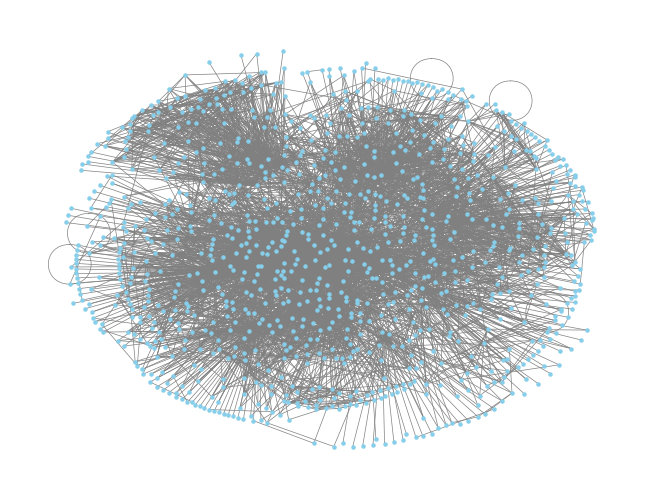

In [5]:
edgelist=pd.read_csv('facebook_data.csv')
G=nx.from_pandas_edgelist(edgelist, source='username1',target='username2'

) # No need to add create_using=nx.DiGraph() if it is an undirected graph

nx.draw(G, with_labels=False, node_size=5,node_color='skyblue',width=0.5, edge_color='gray',pos= nx.kamada_kawai_layout(G))


In [8]:
# Calculate eigenvector centrality
eigenvector_centrality = nx.eigenvector_centrality(G)
# Calculate degree centrality (undirected graph — no in/out degree)
degree_centrality = nx.degree_centrality(G)
# Calculate betweenness centrality
betweenness_centrality = nx.betweenness_centrality(G)
# Calculate closeness centrality
closeness_centrality = nx.closeness_centrality(G)

# Save node attributes
nx.set_node_attributes(G, eigenvector_centrality, 'eigenvector_centrality')
nx.set_node_attributes(G, degree_centrality, 'degree_centrality')
nx.set_node_attributes(G, betweenness_centrality, 'betweenness_centrality')
nx.set_node_attributes(G, closeness_centrality, 'closeness_centrality')

In [10]:
node_attribute = pd.read_csv('facebook_node_attributes.csv')

for index, row in node_attribute.iterrows():
    node_id = row['username']
    attributes = row.drop('username').to_dict()
    if node_id in G.nodes:
        nx.set_node_attributes(G, {node_id: attributes})

In [11]:
attributes_list=[]
for node, attributes in G.nodes(data=True):
    attributes_list.append(attributes)

attributes_df=pd.DataFrame(attributes_list)


/tmp/ipykernel_4990/1955343319.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


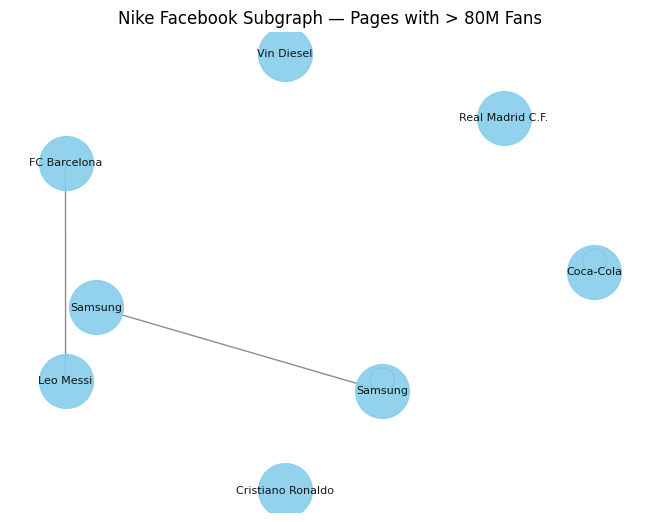

In [12]:
selected_nodes = []
for node, data in G.nodes(data=True):
    if data.get('fan_count', 0) > 80_000_000:
        selected_nodes.append(node)

subgraph = G.subgraph(selected_nodes)

nx.draw(
    subgraph,
    pos=nx.kamada_kawai_layout(subgraph),
    with_labels=True,
    labels={node: data.get('label', node) for node, data in subgraph.nodes(data=True)},
    node_color='skyblue',
    edge_color='gray',
    node_size=1500,
    font_size=8,
    alpha=0.9
)

plt.title("Nike Facebook Subgraph — Pages with > 80M Fans")
plt.tight_layout()
plt.show()

### Your Output — Problem 1.1

```
+------------------------------------------------------------+
| Paste your subgraph visualization here.                    |
|                                                            |
+------------------------------------------------------------+
```

---
> 📤 **Submit to Canvas — Problem 1.1:** Upload the subgraph network visualization.
---

## Problem 1.2
For this subgraph, generate a dataframe to save all attributes of the nodes. Copy the code here. Then, using network centrality measures as support to discuss who Nike should hire as spokesperson if Nike focuses not only on fan count but also network centrality.

Tip: use sort_values(by= "columname", ascending=False) to identify nodes with high centrality measures.

Expected output:
- Code
- Propose 3 spokespeople for Nike. For each spokesperson, discuss their centrality and why you proposed them. Demonstrate your knowledge about different centrality measures in the discussion.

> 💡 **Hint:** See class notebook **Section 1.5** for definitions and calculation of centrality measures, and **Section 1.6** for saving node attributes into a dataframe.

In [13]:
attributes_list = []
for node, attributes in subgraph.nodes(data=True):
    attributes_list.append(attributes)

attributes_df = pd.DataFrame(attributes_list)
attributes_df

,eigenvector_centrality,degree_centrality,betweenness_centrality,closeness_centrality,Unnamed: 0,name,label,category,post_activity,fan_count,talking_about_count,users_can_post
0,0.032254,0.030333,0.009309,0.373129,413,4.079631e+10,Coca-Cola,Food & Beverage,0.00,107873884,7025,yes
1,0.021029,0.012720,0.001328,0.340326,170,1.903472e+10,Real Madrid C.F.,Sports Team,0.09,109425487,904634,no
2,0.005742,0.003914,0.000056,0.301031,480,8.956227e+10,Vin Diesel,Artist,0.01,99132429,47288,no
3,0.049205,0.030333,0.007515,0.375735,748,1.970000e+11,FC Barcelona,Sports Team,0.21,102653035,924723,no
4,0.011788,0.006849,0.001279,0.335302,555,7.224957e+09,Samsung,Electronics Company,0.43,159997828,87893,yes
5,0.050201,0.022505,0.004072,0.375184,193,1.760000e+14,Leo Messi,Athlete,0.01,89957459,680636,no
6,0.052994,0.048924,0.046602,0.402997,10,8.122120e+10,Cristiano Ronaldo,Athlete,0.03,122672469,688102,no
7,0.009169,0.007828,0.000284,0.325374,234,1.270000e+14,Samsung,Computer Company,0.22,159992225,12253,yes


### Your Output — Problem 1.2

```
+------------------------------------------------------------+
| Propose 3 spokespeople for Nike.                           |
| For each spokesperson, discuss their centrality and why    |
| you proposed them.                                         |
|                                                            |
|                                                            |
|                                                            |
+------------------------------------------------------------+
```
Here's the data summarized clearly, and then the spokesperson proposals:

| Page | Fan Count | Eigenvector | Degree | Betweenness | Closeness |
|---|---|---|---|---|---|
| Cristiano Ronaldo | 122.7M | 0.0530 | 0.0489 | 0.0466 | 0.4030 |
| FC Barcelona | 102.7M | 0.0492 | 0.0303 | 0.0075 | 0.3757 |
| Leo Messi | 90.0M | 0.0502 | 0.0225 | 0.0041 | 0.3752 |
| Coca-Cola | 107.9M | 0.0323 | 0.0303 | 0.0093 | 0.3731 |
| Samsung | 160.0M | 0.0118 | 0.0068 | 0.0013 | 0.3353 |
| Vin Diesel | 99.1M | 0.0057 | 0.0039 | 0.0001 | 0.3010 |
| Real Madrid | 109.4M | 0.0210 | 0.0127 | 0.0013 | 0.3403 |

---

Here's the written analysis for Problem 1.2:

---

**Spokesperson 1: Cristiano Ronaldo**

Cristiano Ronaldo is the strongest candidate across every centrality dimension. He has the highest eigenvector centrality (0.0530), meaning he is not only well-connected but connected to other highly influential pages in the network — a signal that his reach amplifies through high-quality relationships. He also leads in degree centrality (0.0489), indicating the most direct connections of any node in the subgraph, and dominates betweenness centrality (0.0466) by a wide margin, meaning he uniquely bridges different communities within the network. His closeness centrality (0.4030) is also the highest, meaning information shared through him spreads to the rest of the network faster than through any other node. Combined with 122.7M fans, Ronaldo offers Nike unmatched network influence.

---

**Spokesperson 2: Leo Messi**

Messi is the second-highest in eigenvector centrality (0.0502), slightly above FC Barcelona, suggesting he is embedded in a cluster of highly influential pages. While his degree centrality (0.0225) is more modest than Ronaldo's, eigenvector centrality tells us that the connections he does have are of very high quality — he reaches powerful nodes with fewer hops. This makes Messi particularly valuable for Nike if the goal is prestige and association with elite networks rather than sheer volume of connections. With 90M fans and strong closeness centrality (0.3752), content featuring Messi would still diffuse efficiently across the network.

---

**Spokesperson 3: FC Barcelona**

FC Barcelona ranks third in eigenvector centrality (0.0492) and matches Coca-Cola in degree centrality (0.0303), but what makes Barcelona particularly compelling for Nike is its category — a Sports Team — which aligns directly with Nike's brand identity. Its closeness centrality (0.3757) is among the highest in the subgraph, meaning it sits near the center of the network and can reach other nodes efficiently. Unlike individual athletes, partnering with a club gives Nike sustained, long-term visibility across an entire fanbase rather than dependence on a single person's public image. With 102.7M fans and strong structural positioning, FC Barcelona offers Nike both reach and brand alignment.
---
> 📤 **Submit to Canvas — Problem 1.2:** Submit your spokesperson proposals with centrality-based justifications.
---

## Problem 1.3

For the whole network (no filtering), perform community detection and plot the network by allowing nodes in different communities to be colored differently. Please note that community detection is only applicable to undirected network, and you will need to use ```G = G.to_undirected()``` to turn the network to an undirected network before you perform community detection.

Expected output:
- Code.
- A network gragh to show communities (no labels are needed for nodes).

> 💡 **Hint:** See class notebook **Section 1.8** for community detection, mapping nodes to community IDs, and coloring nodes by community.

Detected 4 communities.


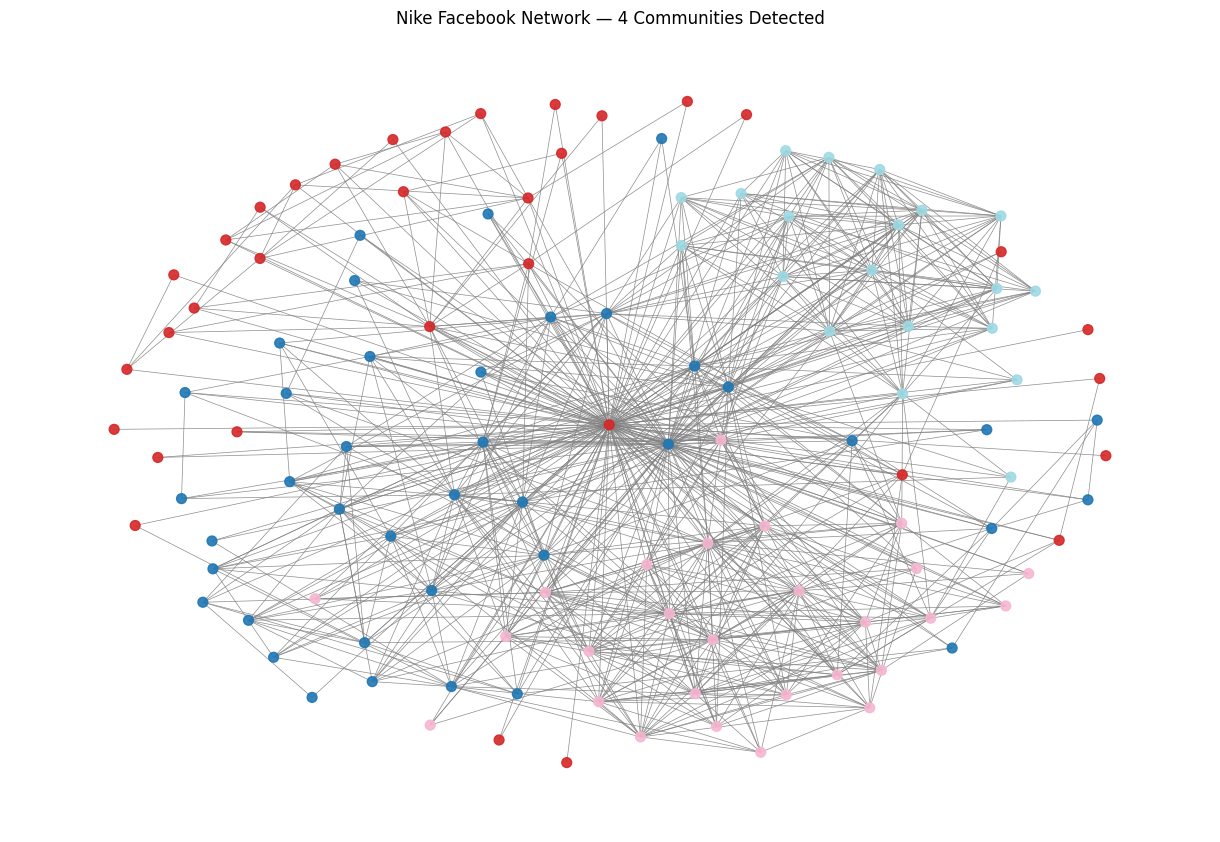

In [20]:
from networkx.algorithms.community import greedy_modularity_communities

# Convert to undirected (required for community detection)
G = G.to_undirected()

# Detect communities using greedy modularity
communities = greedy_modularity_communities(G)
print(f"Detected {len(communities)} communities.")

# Map each node to a community ID
node_community = {}
for i, comm in enumerate(communities):
    for node in comm:
        node_community[node] = i
        G.nodes[node]['community'] = i

# Visualization
pos = nx.kamada_kawai_layout(G)
colors = [node_community[n] for n in G.nodes()]

plt.figure(figsize=(12, 8))
nx.draw(
    G,
    pos=pos,
    node_color=colors,
    with_labels=False,
    node_size=50,
    edge_color='gray',
    width=0.5,
    alpha=0.9,
    cmap=plt.cm.tab20
)
plt.title(f"Nike Facebook Network — {len(communities)} Communities Detected")
plt.show()

# Project 2: Bright Kite
Brightkite was a location-based social networking website. Users were able to "check in" at places by using text messaging or one of the mobile applications and they were able to see who is nearby and who has been there before. The source of the data is [here](https://snap.stanford.edu/data/loc-brightkite.html).

## Problem 2.1
Generate a network using connections on BrightKite and display the network. Note that this is an undirected network and we need to remove ```create_using=nx.DiGraph()``` when generating this network. Upload your network graph below.

Expected Output:
- Code
- Network Plot

> 💡 **Hint:** See class notebook **Section 1.3** for building a graph from an edgelist and **Section 1.4** for visualization parameters.

In [14]:
edgelist=pd.read_csv('brightkite_edgelist.csv')
edgelist

,node1,node2
0,0,1
1,0,2
2,0,3
3,0,4
4,0,5
...,...,...
1575,121,61
1576,121,82
1577,121,88
1578,121,120


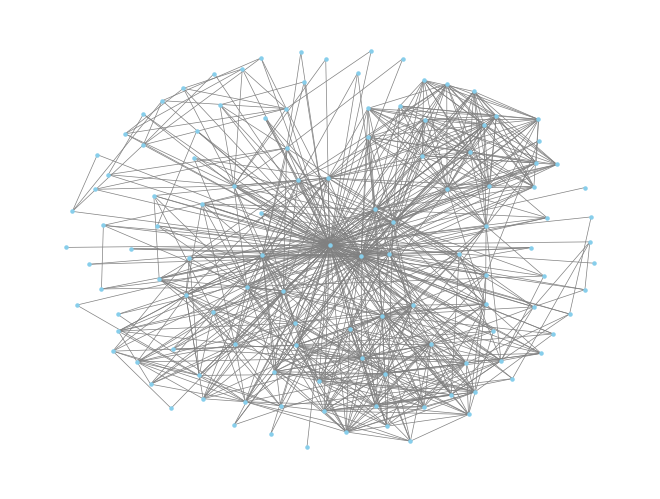

In [15]:
G = nx.from_pandas_edgelist(
    edgelist,
    source='node1',
    target='node2'
)

nx.draw(G, with_labels=False, node_size=5, node_color='skyblue',
        width=0.5, edge_color='gray', pos=nx.kamada_kawai_layout(G))

### Your Output — Problem 2.1

```
+------------------------------------------------------------+
| Paste your BrightKite network plot here.                   |
|                                                            |
+------------------------------------------------------------+
```

---
> 📤 **Submit to Canvas — Problem 2.1:** Upload the BrightKite network visualization.
---

## Problem 2.2
Generate centrality measures and add these network attributes to the network. Note that for undirected network, in-degree and out-degree are the same. We generate degree centrality by using ```degree_centrality = nx.degree_centrality(G)```.

Then, import brightkite_checkins.csv and add external attributes of "checkins" to the network as a new network attribute. We further include node name as an additional feature by using the following code:
```
for node in G.nodes():
    G.nodes[node]['name'] = node
```
Finally, save all node-level attributes into a dataframe and print this dataframe.

Expected output:
- Code
- Answer this question: how many nodes are there in this network?


> 💡 **Hint:** See class notebook **Section 1.5** for calculating centrality measures and adding them as node attributes, and **Section 2.2** for attaching external attributes from a dataframe to network nodes.

In [21]:
# Calculate eigenvector centrality
eigenvector_centrality = nx.eigenvector_centrality(G)
# Calculate degree centrality
degree_centrality = nx.degree_centrality(G)
# Calculate betweenness centrality
betweenness_centrality = nx.betweenness_centrality(G)
# Calculate closeness centrality
closeness_centrality = nx.closeness_centrality(G)

# Save node attributes
nx.set_node_attributes(G, eigenvector_centrality, 'eigenvector_centrality')
nx.set_node_attributes(G, degree_centrality, 'degree_centrality')
nx.set_node_attributes(G, betweenness_centrality, 'betweenness_centrality')
nx.set_node_attributes(G, closeness_centrality, 'closeness_centrality')

Import the checkin data

In [22]:
node_attribute=pd.read_csv("brightkite_checkins.csv")

for index, row in node_attribute.iterrows():
    node_id = int(row['node'])
    attributes = row.drop(['node']).to_dict()  # Convert row to dictionary excluding node_id
    nx.set_node_attributes(G, {node_id: attributes})

Save node attributes into a dataframe

In [23]:
attributes_list = []
for node, attributes in G.nodes(data=True):
    attributes_list.append(attributes)

attributes_df = pd.DataFrame(attributes_list)
attributes_df

,community,eigenvector_centrality,degree_centrality,betweenness_centrality,closeness_centrality,checkins
0,1,0.365188,1.000000,0.610739,1.000000,2100
1,3,0.110019,0.166667,0.000833,0.545455,1210
2,1,0.084494,0.166667,0.007907,0.545455,2100
3,3,0.110094,0.158333,0.003335,0.542986,1807
4,3,0.089532,0.133333,0.000306,0.535714,779
...,...,...,...,...,...,...
116,0,0.040560,0.058333,0.000000,0.515021,43
117,1,0.017976,0.016667,0.000000,0.504202,2
118,0,0.031783,0.058333,0.000460,0.515021,7
119,0,0.046360,0.066667,0.000481,0.517241,4


### Your Output — Problem 2.2

```
+------------------------------------------------------------+
| How many nodes are there in this network?                  |
| Input your answer here.                                    |
|                                                            |
+------------------------------------------------------------+
```
121 Nodes
---
> 📤 **Submit to Canvas — Problem 2.2:** Submit your code and answer the node count question.
---

## Problem 2.3
The platform wants to install a recommendation system to recommend friends. Which users are likely to be friends? Perform an edge prediction based on Jaccard similarity coefficient and print the top 20 edges.

Expected Output:
- Code
- Top 20 edges

> 💡 **Hint:** See class notebook **Section 2.3** for Jaccard-based edge prediction and extracting the top predictions.

In [25]:
import numpy as np

preds = nx.jaccard_coefficient(G)

# Convert generator to list then numpy array
preds_list = list(preds)
preds_array = np.array(preds_list, dtype=object)

# Extract scores and sort descending
scores = preds_array[:, 2]
sorted_indices = np.argsort(-scores)
sorted_preds = preds_array[sorted_indices]

# Print top 20 predictions
for i in range(20):
    u, v, p = sorted_preds[i]
    print(f"({u}, {v}) -> {p:.4f}")

(73, 96) -> 1.0000
(73, 107) -> 1.0000
(111, 119) -> 1.0000
(96, 122) -> 1.0000
(73, 122) -> 1.0000
(107, 122) -> 1.0000
(89, 90) -> 1.0000
(96, 107) -> 1.0000
(1, 11) -> 0.9524
(63, 84) -> 0.7500
(57, 78) -> 0.7500
(19, 78) -> 0.7500
(56, 97) -> 0.7333
(93, 97) -> 0.7333
(39, 89) -> 0.6667
(39, 90) -> 0.6667
(78, 90) -> 0.6667
(62, 90) -> 0.6667
(62, 89) -> 0.6667
(78, 89) -> 0.6667


### Your Output — Problem 2.3

```
+------------------------------------------------------------+
| Paste your top 20 predicted edges here.                    |
|                                                            |
|                                                            |
+------------------------------------------------------------+
```
(73, 96) -> 1.0000
(73, 107) -> 1.0000
(111, 119) -> 1.0000
(96, 122) -> 1.0000
(73, 122) -> 1.0000
(107, 122) -> 1.0000
(89, 90) -> 1.0000
(96, 107) -> 1.0000
(1, 11) -> 0.9524
(63, 84) -> 0.7500
(57, 78) -> 0.7500
(19, 78) -> 0.7500
(56, 97) -> 0.7333
(93, 97) -> 0.7333
(39, 89) -> 0.6667
(39, 90) -> 0.6667
(78, 90) -> 0.6667
(62, 90) -> 0.6667
(62, 89) -> 0.6667
(78, 89) -> 0.6667
---
> 📤 **Submit to Canvas — Problem 2.3:** Submit your code and top 20 edge predictions.
---

## Problem 2.4
Generate a subgraph for nodes with eigenvector centrality higher than 0.1. Plot the network and upload the network graph.
Expected output:
- code
- gragh

> 💡 **Hint:** See class notebook **Section 1.6** for filtering nodes by a threshold attribute value and generating a subgraph.

Nodes with eigenvector centrality > 0.1: 34


/tmp/ipykernel_4990/3723588296.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


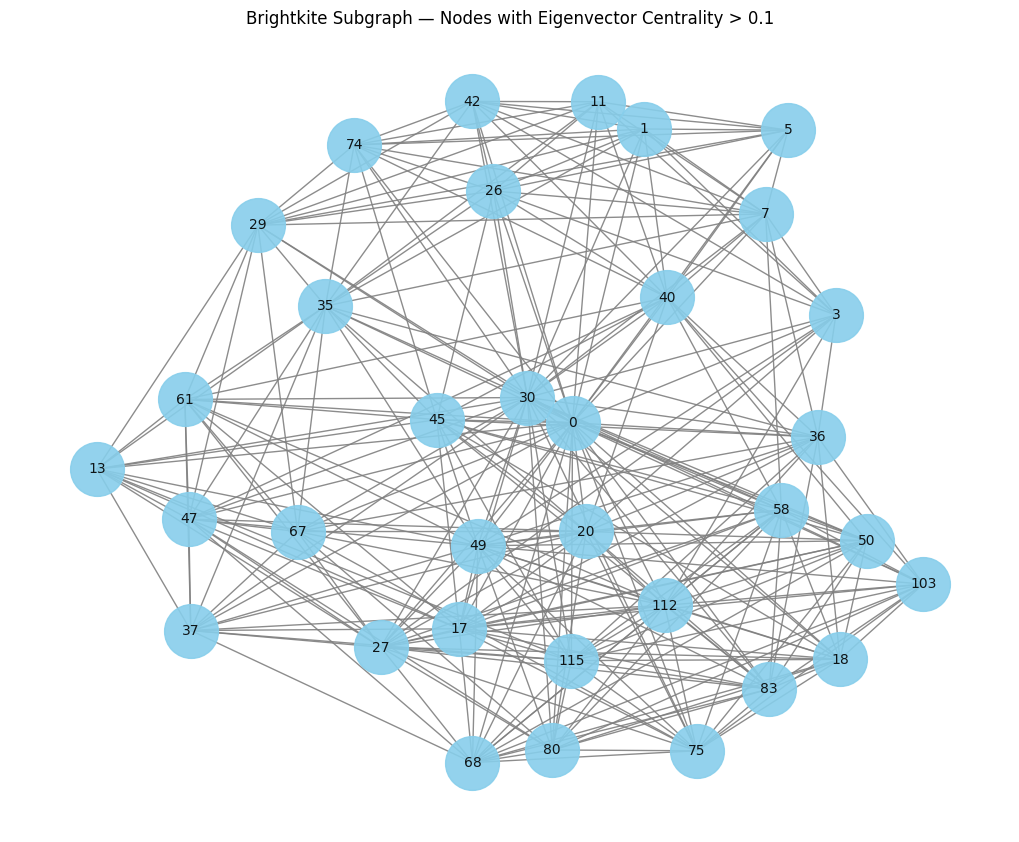

In [29]:
# Filter nodes with eigenvector centrality > 0.1
selected_nodes = []
for node, data in G.nodes(data=True):
    if data.get('eigenvector_centrality', 0) > 0.1:
        selected_nodes.append(node)

print(f"Nodes with eigenvector centrality > 0.1: {len(selected_nodes)}")

# Generate subgraph
subgraph = G.subgraph(selected_nodes)

# Visualize
plt.figure(figsize=(10, 8))
pos = nx.kamada_kawai_layout(subgraph)

nx.draw(
    subgraph,
    pos=pos,
    with_labels=True,
    node_color='skyblue',
    edge_color='gray',
    node_size=1500,
    font_size=10,
    alpha=0.9
)

plt.title("Brightkite Subgraph — Nodes with Eigenvector Centrality > 0.1")
plt.tight_layout()
plt.savefig('brightkite_subgraph.png', dpi=150)
plt.show()

### Your Output — Problem 2.4

```
+------------------------------------------------------------+
| Paste your subgraph visualization here.                    |
|                                                            |
+------------------------------------------------------------+
```

---
> 📤 **Submit to Canvas — Problem 2.4:** Upload the subgraph of nodes with eigenvector centrality > 0.1.
---

In [28]:
import pingouin as pg
import numpy as np

# Create log transformation of checkins
attributes_df['log_checkins'] = np.log(attributes_df['checkins'] + 1)

# Set up regression
df_model = attributes_df[['log_checkins', 'eigenvector_centrality',
                           'degree_centrality', 'betweenness_centrality',
                           'closeness_centrality']].dropna()

# Run linear regression
result = pg.linear_regression(
    df_model.drop(columns='log_checkins'),
    df_model['log_checkins']
)

# Display rounded results
result[['names', 'coef', 'pval']] = result[['names', 'coef', 'pval']].round(3)
result[['names', 'coef', 'pval']]


,names,coef,pval
0,Intercept,196.484,0.004
1,eigenvector_centrality,19.648,0.207
2,degree_centrality,110.485,0.007
3,betweenness_centrality,131.380,0.006
4,closeness_centrality,-386.479,0.004


## Problem 2.5
Run a linear regression to explore how centrality measures affect the outcome of log(checkins+1).
Expected output:
- code
- regression results
- interpretation

> 💡 **Hint:** See class notebook **Section 1.7** for setting up node attributes as model inputs and running a linear regression.

In [33]:
import pingouin as pg
import numpy as np

# Create log transformation of checkins
attributes_df['log_checkins'] = np.log(attributes_df['checkins'] + 1)

# Set up model dataframe
df_model = attributes_df[['log_checkins', 'eigenvector_centrality',
                           'degree_centrality', 'betweenness_centrality',
                           'closeness_centrality']].dropna()

# Run linear regression
result = pg.linear_regression(
    df_model.drop(columns='log_checkins'),
    df_model['log_checkins']
)

# Display rounded results
result[['names', 'coef', 'pval']] = result[['names', 'coef', 'pval']].round(3)
result[['names', 'coef', 'pval']]



,names,coef,pval
0,Intercept,196.484,0.004
1,eigenvector_centrality,19.648,0.207
2,degree_centrality,110.485,0.007
3,betweenness_centrality,131.380,0.006
4,closeness_centrality,-386.479,0.004


In [34]:
print(f"R² = {result['r2'].values[0].round(3)}")

R² = 0.394


### Your Output — Problem 2.5

```
+------------------------------------------------------------+
| Interpret the regression results here.                     |
| - Which centrality measures are significant predictors     |
|   of check-ins?                                            |
| - What does the R² tell you about the model?               |
|                                                            |
|                                                            |
+------------------------------------------------------------+
```

---
> 📤 **Submit to Canvas — Problem 2.5:** Submit your  regression results and interpretation. (keep your code here)
---

# Problem 3

In our class exercise, we used function 'search_tweets_by_topic' from package itom6219 to retrieve tweets based on topic.
In this homework exercise, I designed a workflow to get you familiar with how to build a query to retrieve posts from X.
Take a moment to read this page: https://docs.x.com/x-api/posts/search/integrate/build-a-query


## Problem 3.1 Start with a basic query
- Create a query that includes the keyword of both "SMU" and "Football". Note that the AND operator is a space in X API.
- Set `include_mentions=False`
- `max_results=10`
- Save the output to `tweets_dict`

> 💡 **Hint:** See class notebook **Section 2.1** for the query syntax table and examples of combining keywords with Boolean operators.

In [38]:
import os
from itom6219 import  user_info, user_tweets, user_tweets_all, search_tweets_by_topic  ,extract_user_mention_edges
from google.colab import userdata
os.environ["BEARER_TOKEN"] =userdata.get('BEARER_TOKEN')
tweets_dict = search_tweets_by_topic(
    topic="SMU Football",
    include_mentions=False,
    max_results=10
)

ModuleNotFoundError: No module named 'itom6219'

use `tweets_df = pd.DataFrame(tweets_dict['data'])` to turn the dictionary into a dataframe.

Use the code `pd.set_option('display.max_colwidth', None)` to allow full display of pandas content

In [37]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
tweets_df = pd.DataFrame(tweets_dict['data'])
tweets_df

NameError: name 'tweets_dict' is not defined

## Problem 3.3 Broaden for better coverage

Broaden coverage by using OR to include additional sports topics (e.g., `(SMU Football) OR (SMU Basketball)`).

> 💡 **Hint:** See class notebook **Section 2.1** for examples of using Boolean OR to combine multiple topic queries.

In [ ]:
tweets_dict = search_tweets_by_topic(
    topic="", # Fill in your query here
    include_mentions=False,
    max_results=10
)
tweets_df = pd.DataFrame(tweets_dict['data'])
tweets_df

## Problem 3.4 Add emotion filters

Now add emotion keywords (e.g., `(happy OR happiness OR excited OR elated)`) to your query from 3.3. Use grouping with parentheses so that the query matches tweets about SMU sports AND containing an emotion keyword.

> 💡 **Hint:** See class notebook **Section 2.1** for examples of grouping with parentheses to combine topic and emotion filters in a single query.

In [ ]:
tweets_dict = search_tweets_by_topic(
    topic="", # Fill in your query here
    include_mentions=False,
    max_results=10
)
tweets_df = pd.DataFrame(tweets_dict['data'])
tweets_df

## Problem 3.5 Export tweets to CSV file (only the last file)

This question is a practice of the function `to_csv` which can export a pandas dataframe as a csv file. It will be listed in the file section of Google Colab for you to download and upload to Canvas.

In [ ]:
tweets_df.to_csv(# Fill in your csv file name here)

> 📤 **Submit to Canvas — Problem 3.5:** Submit a csv file with your collected tweet(s).